🎓 Predicting Student Mental Health Score from Social Media Usage
Problem: We're predicting a student's Mental_Health_Score (a continuous score from ~3 to ~10) using their social media habits, study time, sleep, physical activity, and stress level. This is a regression problem since the target is a number, not a category.

Dataset: Student_Social_Media_And_Mental_Health_Impact.csv — 5,000 students, 13 columns covering demographics (Age, Gender, Country), platform usage (Avg_Daily_Usage_Hours, Daily_Unlocks, Most_Used_Platform), lifestyle (Study_Hours, Sleep_Hours_Per_Night, Physical_Activity_Hours), and Stress_Level.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r'C:\Users\sipug\OneDrive\Desktop\ML_PROJECTS\Mental Health Score\Student Social Media And Mental Health Impact.csv')
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
df.shape

(5000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [6]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(2)

In [8]:
df=df.drop_duplicates()

In [9]:
df

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [10]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


# EDA

In [11]:
a=df.select_dtypes(include='number').columns

In [12]:
numeric_col=[i for i in a]
numeric_col

['Age',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Mental_Health_Score']

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

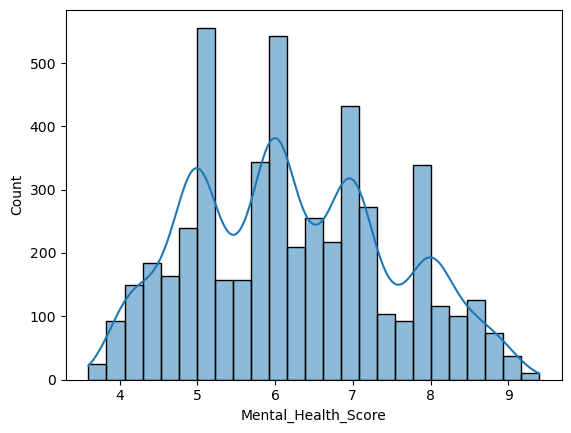

In [13]:
#Creating a histplot
sns.histplot(df['Mental_Health_Score'],kde=True)

In [14]:
#Correlation
correlat=df.corr(numeric_only=True)
correlat

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
Age,1.000000,-0.069961,-0.074337,0.082860,0.013071,0.088545,0.100464
Avg_Daily_Usage_Hours,-0.069961,1.000000,0.960190,-0.878665,-0.625764,-0.808370,-0.816485
Daily_Unlocks,-0.074337,0.960190,1.000000,-0.853359,-0.602845,-0.781820,-0.790830
Study_Hours,0.082860,-0.878665,-0.853359,1.000000,0.560618,0.730145,0.752483
Physical_Activity_Hours,0.013071,-0.625764,-0.602845,0.560618,1.000000,0.507953,0.521591
Sleep_Hours_Per_Night,0.088545,-0.808370,-0.781820,0.730145,0.507953,1.000000,0.766462
Mental_Health_Score,0.100464,-0.816485,-0.790830,0.752483,0.521591,0.766462,1.000000


<Axes: >

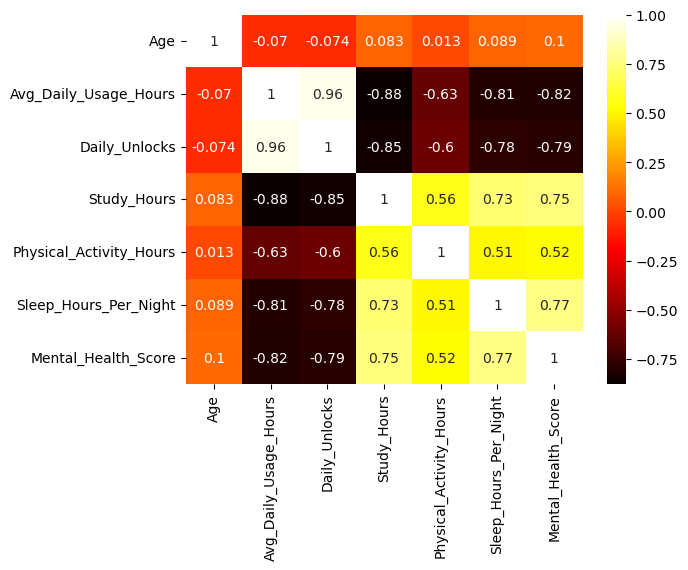

In [15]:
sns.heatmap(correlat,annot=True,cmap='hot')

# Stress Level vs Mental Health Score

In [16]:
b=df.select_dtypes(include=object).columns

In [17]:
obj_col=[i for i in b]
obj_col

['Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Stress_Level']

In [18]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

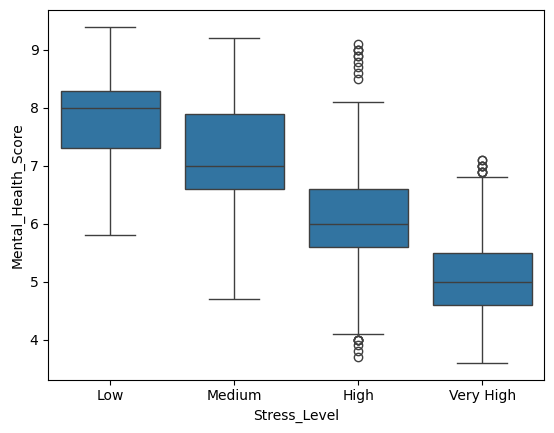

In [19]:
order=['Low','Medium','High' , 'Very High' ]
sns.boxplot(data=df,x='Stress_Level',y='Mental_Health_Score',order=order)

# Similarly for every object column

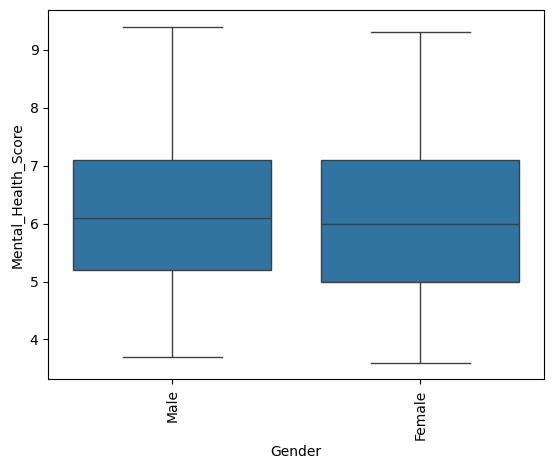

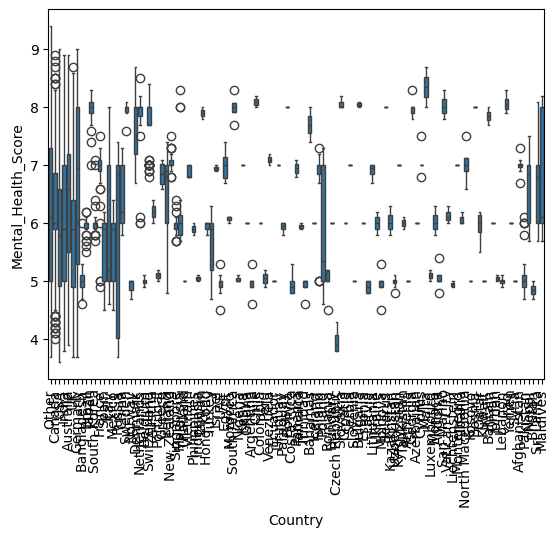

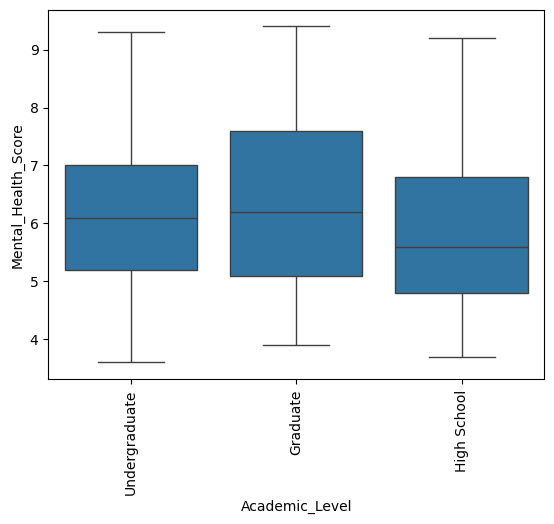

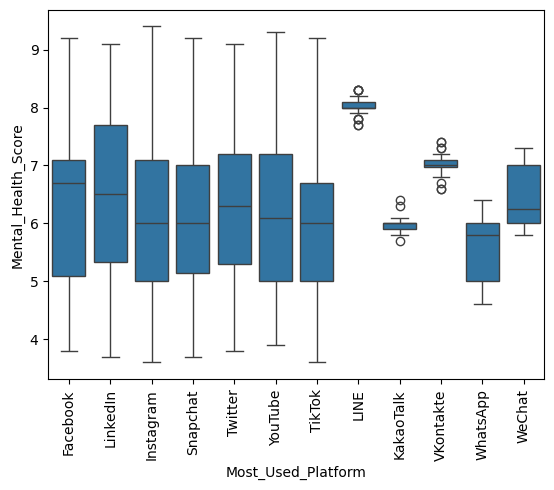

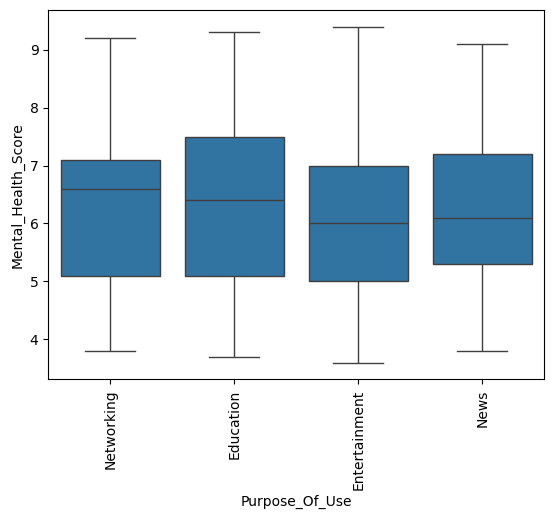

In [20]:
for i in obj_col:
    if i=='Stress_Level':
        continue
    sns.boxplot(data=df,x=i,y='Mental_Health_Score')
    plt.xticks(rotation=90)
    plt.show()

# Numerical colmns VS Mental Health Score

In [21]:
numeric_col

['Age',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Mental_Health_Score']

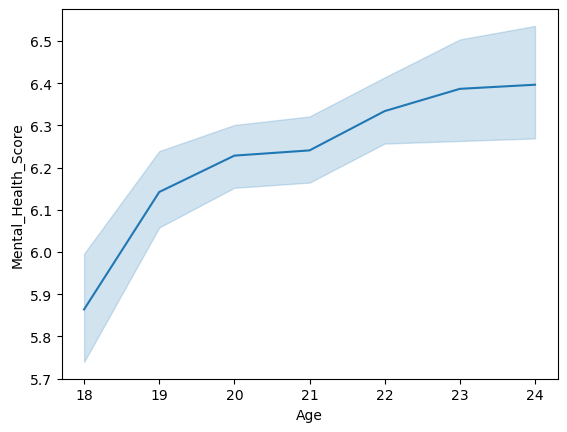

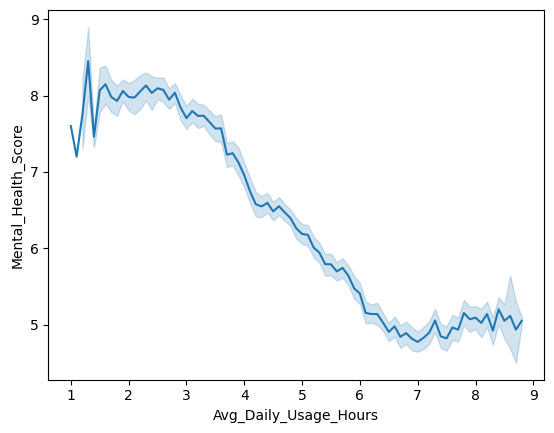

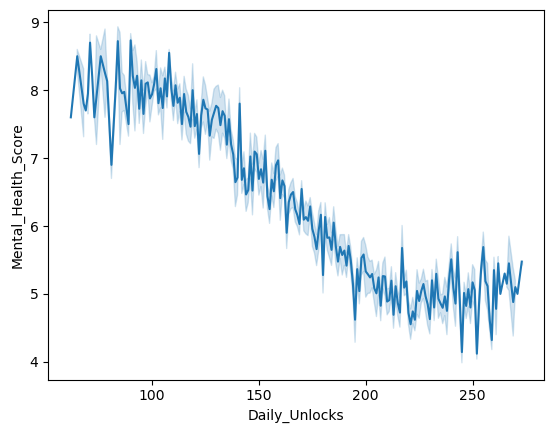

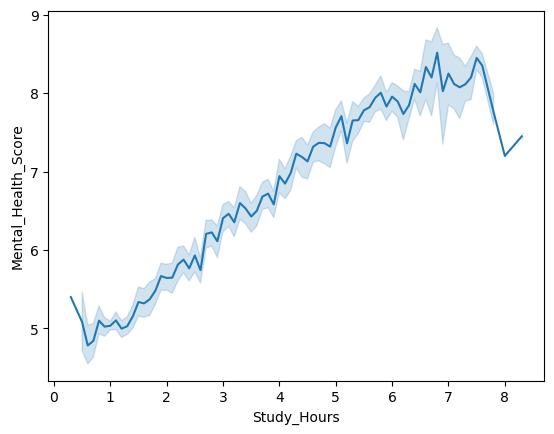

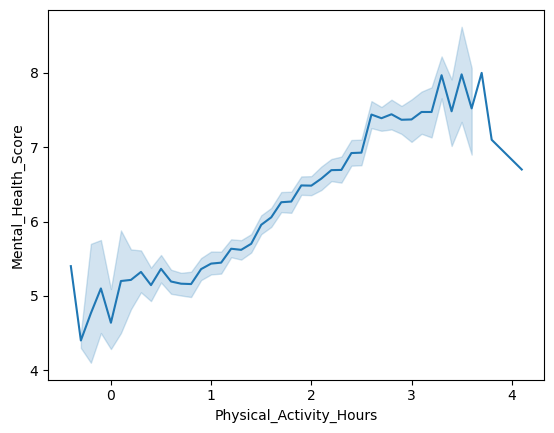

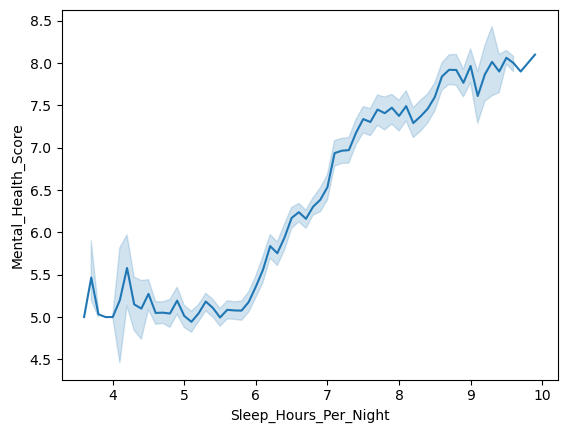

In [22]:
for i in numeric_col:
    if i =='Mental_Health_Score':
        continue
    sns.lineplot(data=df,x=i,y='Mental_Health_Score')
    # plt.xticks(rotation=90)
    plt.show()

In [23]:
obj_col

['Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Stress_Level']

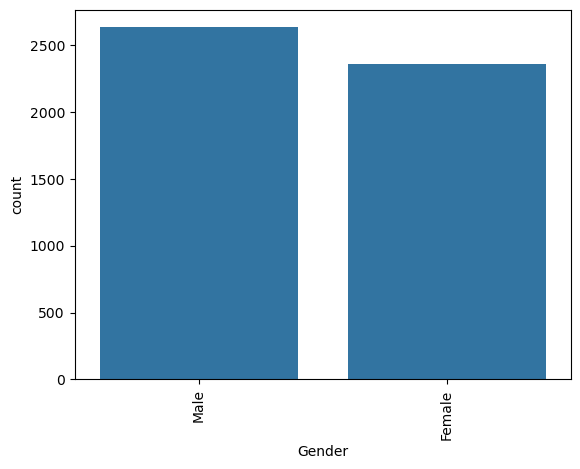

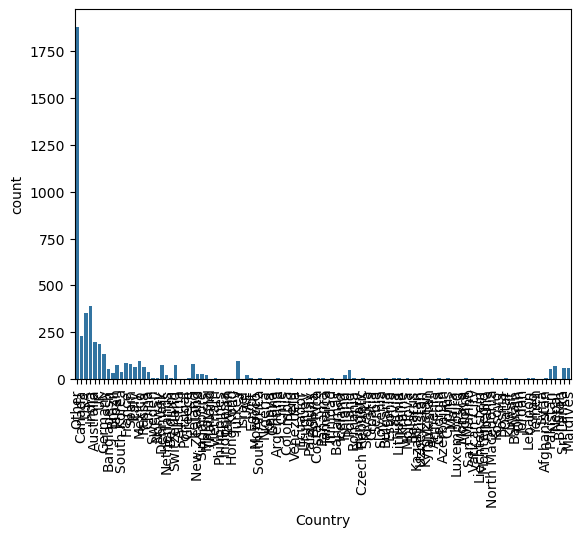

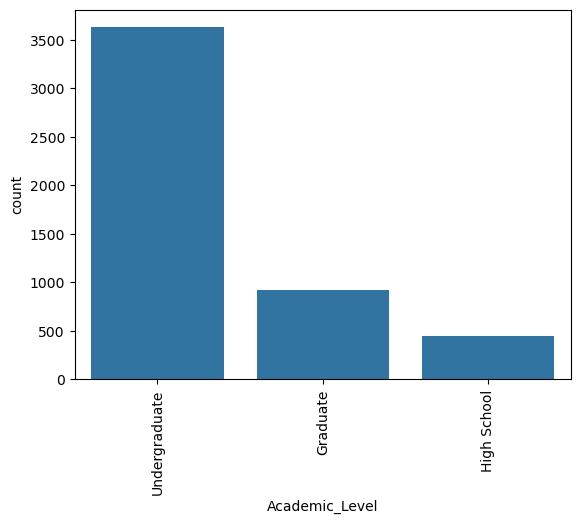

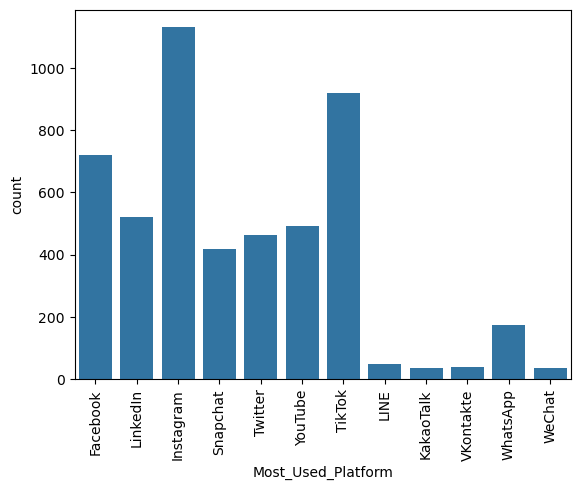

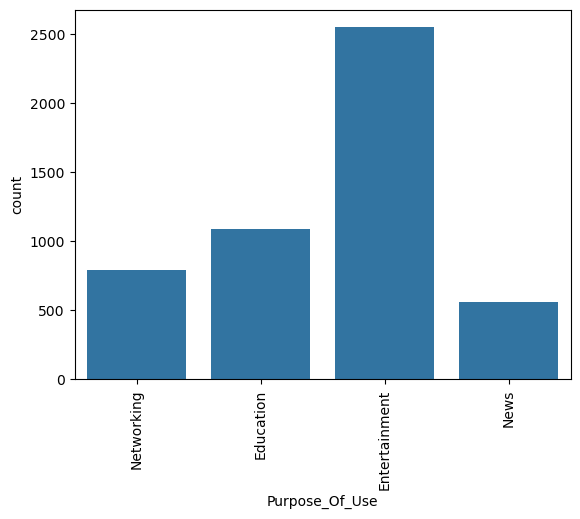

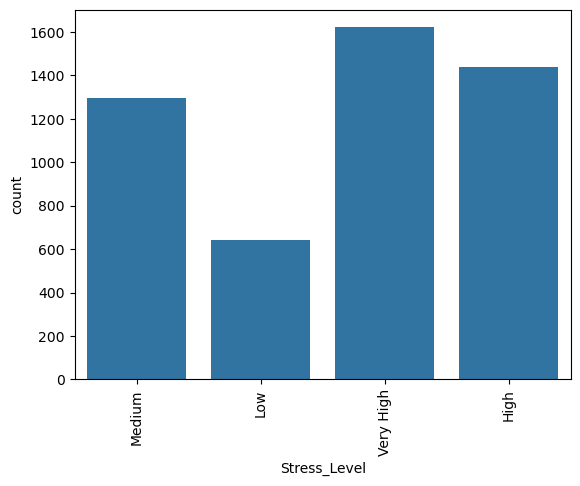

In [24]:
for i in obj_col:
    sns.countplot(data=df,x=i)
    plt.xticks(rotation=90)
    plt.show()

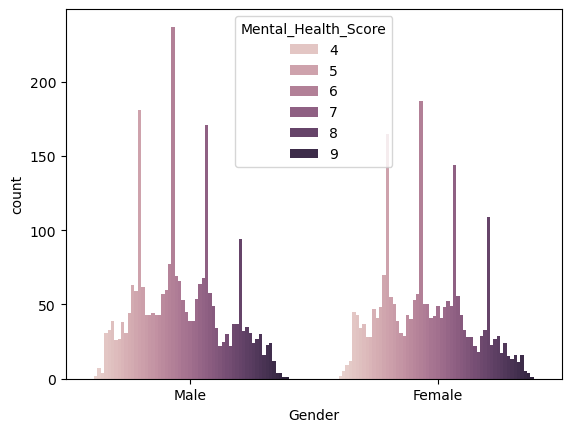

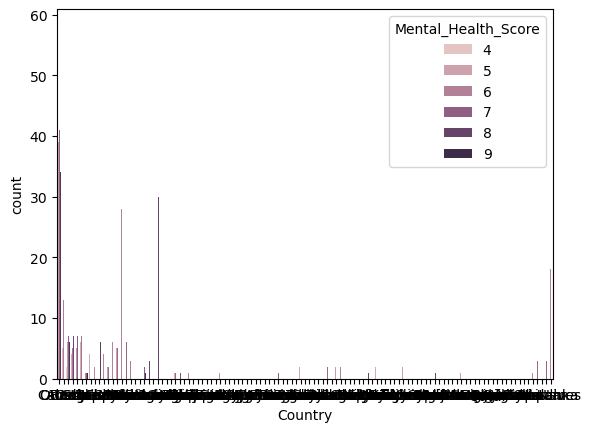

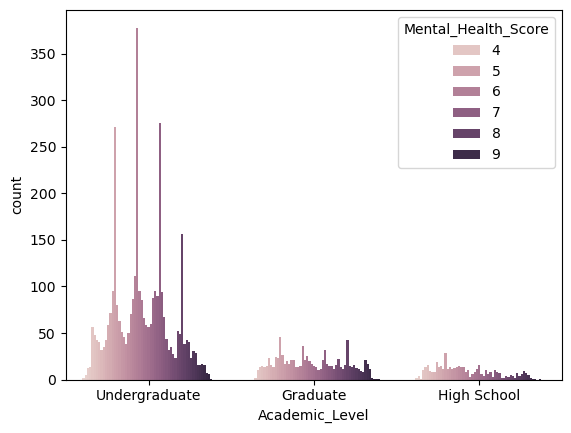

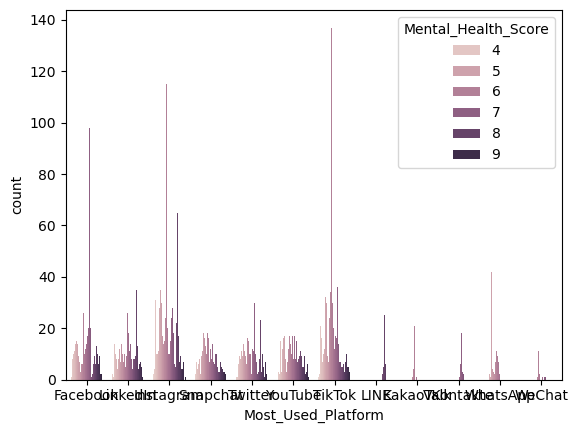

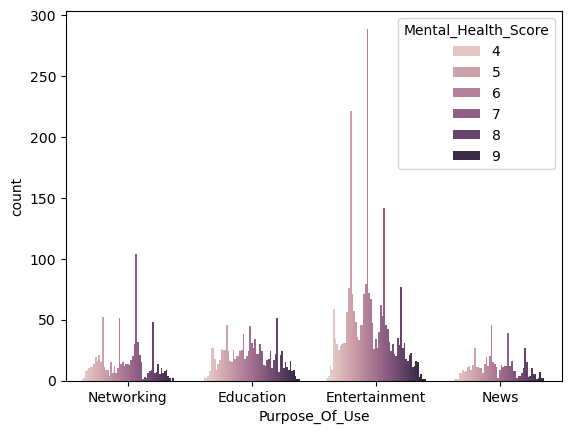

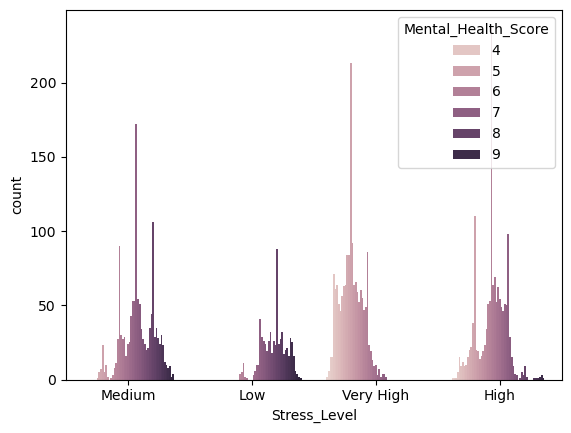

In [25]:
for i in obj_col:
    sns.countplot(data=df,x=i,hue='Mental_Health_Score')
    plt.show()

In [26]:
e=df['Most_Used_Platform'].value_counts()
e

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      522
YouTube       491
Twitter       462
Snapchat      419
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

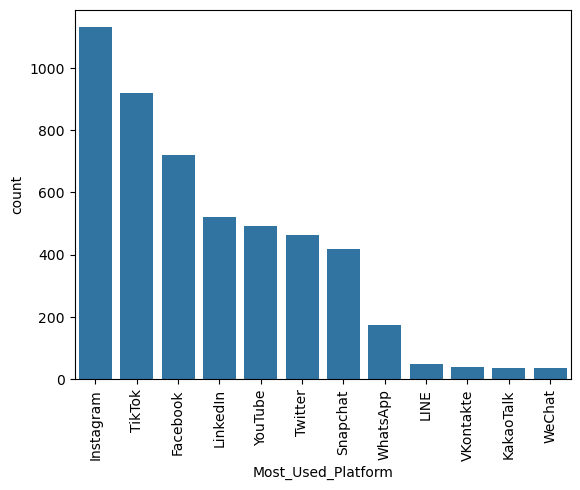

In [27]:
sns.countplot(data=df,x='Most_Used_Platform',order=[i for i in e.index])
plt.xticks(rotation=90)
plt.show()

# Checking Outliers


In [28]:
numeric_col.pop()

'Mental_Health_Score'

In [29]:
numeric_col

['Age',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night']

In [30]:
n=df.select_dtypes(include='number')
Q1=n.quantile(0.25)
Q3=n.quantile(.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outlier=((n<lower_bound)|(n>upper_bound)).sum()
outlier

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64

# Correcting Outlier

In [31]:
df['Study_Hours']=df['Study_Hours'].clip(lower=lower_bound['Study_Hours'],upper=upper_bound['Study_Hours'])
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0,upper=upper_bound['Physical_Activity_Hours'])

In [32]:
n=df.select_dtypes(include='number')
Q1=n.quantile(0.25)
Q3=n.quantile(.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outlier=((n<lower_bound)|(n>upper_bound)).sum()
outlier

Age                        0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Mental_Health_Score        0
dtype: int64

In [33]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008383,1.750880,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636767,0.666464,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.250000,3.550000,9.900000,9.400000


# SKEWNESS

In [34]:
n.skew()

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.435833
Physical_Activity_Hours    0.043933
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

In [35]:
a=df.loc[df['Country'].map(df['Country'].value_counts())>=100,'Country'].unique()

In [36]:
list(a)

['Other', 'Canada', 'USA', 'India', 'Australia', 'UK', 'Germany']

In [37]:
len(list(a))

7

In [38]:
Other=df.loc[df['Country'].map(df['Country'].value_counts())<100,'Country'].unique().tolist()

In [39]:
df['Country']=df['Country'].replace(Other,'Other')

In [40]:
df['Country'].value_counts()

Country
Other        3506
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Name: count, dtype: int64

In [41]:
g=[f'{i}:{df[i].unique()}' for i in df.columns]

In [42]:
g

['Age:[21 23 22 18 24 19 20]',
 "Gender:['Male' 'Female']",
 "Country:['Other' 'Canada' 'USA' 'India' 'Australia' 'UK' 'Germany']",
 "Academic_Level:['Undergraduate' 'Graduate' 'High School']",
 "Most_Used_Platform:['Facebook' 'LinkedIn' 'Instagram' 'Snapchat' 'Twitter' 'YouTube' 'TikTok'\n 'LINE' 'KakaoTalk' 'VKontakte' 'WhatsApp' 'WeChat']",
 "Purpose_Of_Use:['Networking' 'Education' 'Entertainment' 'News']",
 'Avg_Daily_Usage_Hours:[4.  1.6 4.6 7.  7.5 4.1 8.  6.  4.7 3.6 7.6 2.4 6.2 2.7 5.2 6.5 6.8 6.9\n 5.5 2.  5.1 7.1 2.8 7.4 5.6 7.3 2.3 5.9 6.7 4.5 5.7 8.3 8.1 7.2 7.9 3.4\n 4.4 3.  1.7 1.8 4.9 8.2 2.9 6.4 2.5 3.2 8.4 5.8 3.7 3.3 3.1 3.5 3.8 5.\n 2.6 5.3 1.9 6.1 6.3 7.8 5.4 4.3 1.5 6.6 7.7 8.5 4.2 2.2 3.9 4.8 2.1 8.6\n 8.8 1.  8.7 1.2 1.4 1.3 1.1]',
 'Daily_Unlocks:[134  73 166 220 237 138 246 209 154 130 133 240  86 189 120 155 226 211\n 212 183 100 170 110 113 210 208 107 249 175 103 235 234 185 219 214 176\n 204 108 259 222 256 132 182 223 244 258 233 239 136 139 180 106  94 1

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4998 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4998 non-null   int64  
 1   Gender                   4998 non-null   object 
 2   Country                  4998 non-null   object 
 3   Academic_Level           4998 non-null   object 
 4   Most_Used_Platform       4998 non-null   object 
 5   Purpose_Of_Use           4998 non-null   object 
 6   Avg_Daily_Usage_Hours    4998 non-null   float64
 7   Daily_Unlocks            4998 non-null   int64  
 8   Study_Hours              4998 non-null   float64
 9   Physical_Activity_Hours  4998 non-null   float64
 10  Sleep_Hours_Per_Night    4998 non-null   float64
 11  Stress_Level             4998 non-null   object 
 12  Mental_Health_Score      4998 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 546.7+ KB


In [44]:
df['Country'].value_counts()

Country
Other        3506
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Name: count, dtype: int64

In [45]:
df

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [46]:
# We separate columns to apply dfferent functions on it and then add them.
skwed_col=['Study_Hours']
other_numer_col=['Age',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night']
ordinal_col=['Stress_Level']
one_hot_encode=['Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use']
total_cols=skwed_col+other_numer_col+ordinal_col+one_hot_encode


In [47]:
X=df[total_cols]
Y=df['Mental_Health_Score']

# Preprocessing Using Column Transformer and Create Pipeline


In [48]:
# 4 pipelines will be created for each column we have created.
#1.Skew Pipeline for skewed features
#2.Numeric Pipeline for numeric features
#3. Ordinal Pipeline for ordinal Encode features
#4. One hot encode pipline for one hot encode features

In [49]:
#importing pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OrdinalEncoder,OneHotEncoder
#1.Skewed features
skew_pipeline=Pipeline(steps=[
    ('Log_Transform',FunctionTransformer(np.log1p)),
    ('scaler',StandardScaler())
])
num_pipeline=Pipeline(steps=[
    ('scaler',StandardScaler())
])
ordinal_pipeline=Pipeline(steps=[
    ('Encoding',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
])
Onehot_pipeline=Pipeline(steps=[
    ('Encode',OneHotEncoder(handle_unknown='ignore'))
])

# Create Column Tranformer

In [50]:
from sklearn.compose import ColumnTransformer
First_pipe=ColumnTransformer(transformers=[
    ('Skewed_Pipeline',skew_pipeline,skwed_col),
    ('Number_Pipeline',num_pipeline,numeric_col),
    ('Ordinal_Pipeline',ordinal_pipeline,ordinal_col),
    ('Onehot_Pipeline',Onehot_pipeline,one_hot_encode)
])

In [51]:
First_pipe

,transformers,"[('Skewed_Pipeline', ...), ('Number_Pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,func,<ufunc 'log1p'>
,inverse_func,None
,validate,False


In [52]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.30,random_state=42)

# Creating Pipelines for Model
## Linear Regreesion Model Pipeline

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
lr_pipeline=Pipeline(steps=[
    ('Preprocessing',First_pipe),
    ('Regression',LinearRegression())
])
lr_pipeline.fit(x_train,y_train)  
y_pred=lr_pipeline.predict(x_test)
lr_train=lr_pipeline.predict(x_train)
lr_mae=mean_absolute_error(y_test,y_pred)
r2_testing=r2_score(y_test,y_pred)
r2_training=r2_score(y_train,lr_train)#Accuracy of training
print('Accuracy of training',r2_training)
print('Accuracy of testing',r2_testing)
print('MAE',lr_mae)

Accuracy of training 0.7195434500078133
Accuracy of testing 0.737598725248958
MAE 0.5389439151962335


# RANDOM FOREST

In [54]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline=Pipeline(steps=[
    ('Preprocessing',First_pipe),
    ('Random Forest',RandomForestRegressor(random_state=42))
])
rf_pipeline.fit(x_train,y_train)
y_pred_test=rf_pipeline.predict(x_test)
y_pred_train=rf_pipeline.predict(x_train)
r2__testing=r2_score(y_test,y_pred_test)
r2__training=r2_score(y_train,y_pred_train)
mae=mean_absolute_error(y_test,y_pred_test)
msa=mean_squared_error(y_test,y_pred_test)
print('Accuracy Testing',r2__testing)
print('Accuracy Training',r2__training)
print('MAE',mae)
print('MSA',msa)


Accuracy Testing 0.8754031376727166
Accuracy Training 0.9805943762705256
MAE 0.35131736666666674
MSA 0.21883907766166666


# Hyperparameter Tuning for correcting Overfitting and Underfitting

In [55]:
from sklearn.model_selection import RandomizedSearchCV
param_grid={
    'Random Forest__n_estimators':[100,200,300,500,1000],
    'Random Forest__criterion':['friedman_mse', 'squared_error', 'absolute_error', 'poisson'],
    'Random Forest__max_depth':[2,5,8,15],
    'Random Forest__min_samples_split':[2,5,7,9],
    'Random Forest__max_features':['sqrt','log2']
}
rcv=RandomizedSearchCV(rf_pipeline,param_grid,n_iter=15,cv=10,random_state=42,n_jobs=-1)
rcv.fit(x_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'Random Forest__criterion': ['friedman_mse', 'squared_error', ...], 'Random Forest__max_depth': [2, 5, ...], 'Random Forest__max_features': ['sqrt', 'log2'], 'Random Forest__min_samples_split': [2, 5, ...], ...}"
,n_iter,15
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [56]:
rcv.best_params_

{'Random Forest__n_estimators': 200,
 'Random Forest__min_samples_split': 7,
 'Random Forest__max_features': 'sqrt',
 'Random Forest__max_depth': 15,
 'Random Forest__criterion': 'squared_error'}

In [57]:
rcv.best_estimator_

,steps,"[('Preprocessing', ...), ('Random Forest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Skewed_Pipeline', ...), ('Number_Pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
y_hyper_pred=rcv.predict(x_test)
y_hyper_pr=rcv.predict(x_train)
print(f'R2score for random forest after hyperparameter Tuning is {r2_score(y_test,y_hyper_pred)}')
print(f'R2score for random forest after hyperparameter Tuning is {r2_score(y_train,y_hyper_pr)}')

R2score for random forest after hyperparameter Tuning is 0.858557194566929
R2score for random forest after hyperparameter Tuning is 0.9314853760417867


# Saving Model

In [59]:
import joblib
joblib.dump(rcv.best_estimator_,'RF_tune_pipeline.pkl')

['RF_tune_pipeline.pkl']

In [60]:
df.columns.tolist()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score']